In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import MultiComparison

In [ ]:
file_path = r"C:\Users\phunk\OneDrive\Desktop\MyProject\Return Rate\data\สรุปยอดขาย Grab.xlsx"
df = pd.read_excel(file_path)

In [41]:
df.head()

,Date,Day Name,Week of Month,Ads,Qty,Sales
0,2025-01-06,Monday,2,0.0,1,169.0
1,2025-01-08,Wednesday,2,0.0,3,676.0
2,2025-01-09,Thursday,2,0.0,4,770.0
3,2025-01-10,Friday,2,124.4,4,491.0
4,2025-01-11,Saturday,2,0.0,0,0.0


In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 321 entries, 0 to 320
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           321 non-null    datetime64[us]
 1   Day Name       321 non-null    str           
 2   Week of Month  321 non-null    int64         
 3   Ads            321 non-null    float64       
 4   Qty            321 non-null    int64         
 5   Sales          321 non-null    float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(1)
memory usage: 15.2 KB


In [43]:
df["Week of Month"] = df["Week of Month"].replace(6, 5)
df["Week of Month"] = df["Week of Month"].astype(str)

In [53]:
df.describe()

,Date,Ads,Qty,Sales
count,321,321.000000,321.000000,321.000000
mean,2025-07-30 09:16:15.700934,81.443801,4.445483,810.047726
min,2025-01-06 00:00:00,0.000000,0.000000,0.000000
25%,2025-04-12 00:00:00,0.000000,1.000000,255.000000
50%,2025-07-23 00:00:00,76.970000,4.000000,707.370000
75%,2025-11-23 00:00:00,131.340000,7.000000,1212.950000
max,2026-02-27 00:00:00,396.070000,15.000000,3512.000000
std,NaN,76.829696,3.631157,673.906273


In [45]:
for col in df.select_dtypes(include=["str"]).columns:
    print(f"{col}: {df[col].nunique()}")

Day Name: 7
Week of Month: 5


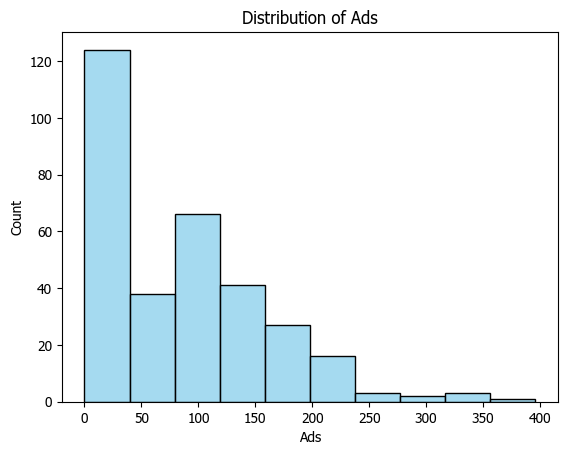

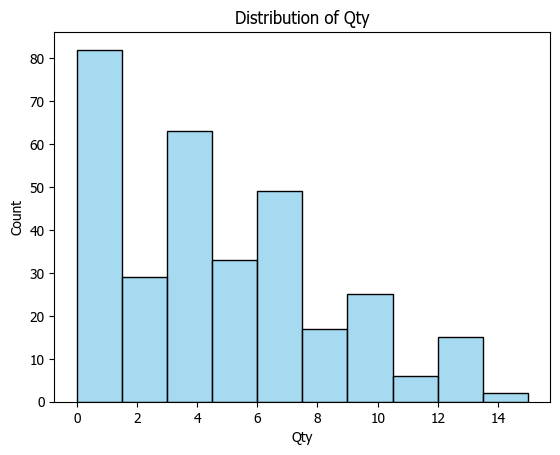

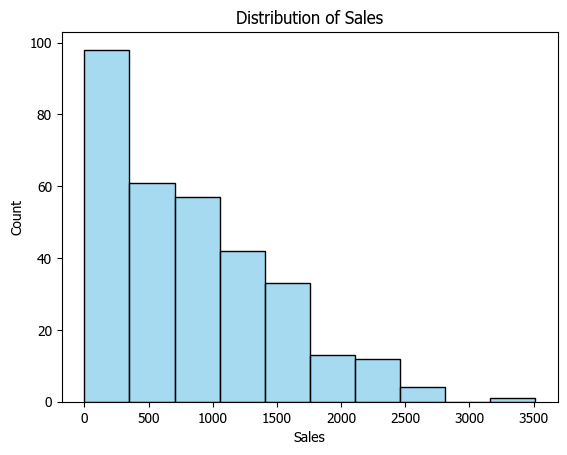

In [46]:
for col in df.select_dtypes(include="number").columns:
    plt.Figure(figsize=(10, 4))
    sns.histplot(df[col], bins=10, color="skyblue")
    plt.title(f'Distribution of {col}')
    plt.show()

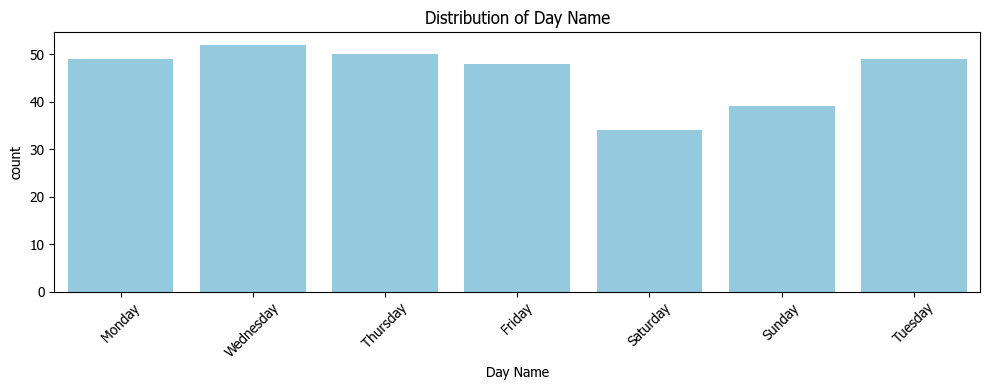

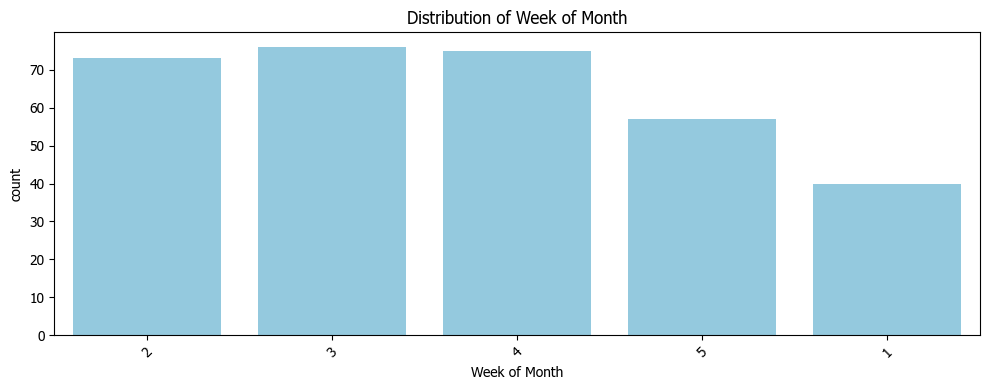

In [47]:
plt.rcParams['font.family'] = 'Tahoma'
plt.rcParams['axes.unicode_minus'] = False

for col in df.select_dtypes(include=["object", "category", "string"]).columns:
    plt.figure(figsize=(10, 4))
    sns.countplot(data=df, x=col, color="skyblue")
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [49]:
print("--- รายงานผลการทดสอบ Normality (ความเป็นเส้นโค้งปกติ) ---")
print("สมมติฐานหลัก (H0): ข้อมูลมีการแจกแจงเป็นเส้นโค้งปกติ (Normal Distribution)\n")

# วนลูปทดสอบเฉพาะคอลัมน์ที่เป็นตัวเลข
for col in df.select_dtypes(include="number").columns:
    # ตัดค่า null ออกก่อนทดสอบ
    data_clean = df[col].dropna()

    # ตรวจสอบจำนวนข้อมูลเบื้องต้น
    if len(data_clean) < 3:
        continue

    # ใช้ D'Agostino's K-squared Test (เหมาะสำหรับข้อมูลขนาดใหญ่)
    stat, p_value = stats.normaltest(data_clean)

    # คำนวณค่า Kurtosis (ความโด่ง) เพิ่มเติมเพื่อใช้เขียนคู่กับ Skewness
    kurt_val = data_clean.kurtosis()
    skew_val = data_clean.skew()

    print(f"คอลัมน์: {col}")
    print(f"  - ค่า Skewness (ความเบ้): {skew_val:.4f}")
    print(f"  - ค่า Kurtosis (ความโด่ง): {kurt_val:.4f}")
    print(f"  - p-value จาก Normality Test: {p_value:.4e}")

    # แปลผลทางสถิติด้วยค่า p-value (Alpha = 0.05)
    if p_value > 0.05:
        print(
            "  -> สรุปผล: ยอมรับ H0 ข้อมูลมี การแจกแจงเป็นปกติ (Normal Distribution) อย่างมีนัยสำคัญ"
        )
    else:
        print(
            "  -> สรุปผล: ปฏิเสธ H0 ข้อมูล ไม่เป็นปกติ (Non-normal Distribution) อย่างมีนัยสำคัญ"
        )
    print("-" * 65)

--- รายงานผลการทดสอบ Normality (ความเป็นเส้นโค้งปกติ) ---
สมมติฐานหลัก (H0): ข้อมูลมีการแจกแจงเป็นเส้นโค้งปกติ (Normal Distribution)

คอลัมน์: Ads
  - ค่า Skewness (ความเบ้): 0.8770
  - ค่า Kurtosis (ความโด่ง): 0.6501
  - p-value จาก Normality Test: 1.0434e-08
  -> สรุปผล: ปฏิเสธ H0 ข้อมูล ไม่เป็นปกติ (Non-normal Distribution) อย่างมีนัยสำคัญ
-----------------------------------------------------------------
คอลัมน์: Qty
  - ค่า Skewness (ความเบ้): 0.5912
  - ค่า Kurtosis (ความโด่ง): -0.3888
  - p-value จาก Normality Test: 5.3520e-05
  -> สรุปผล: ปฏิเสธ H0 ข้อมูล ไม่เป็นปกติ (Non-normal Distribution) อย่างมีนัยสำคัญ
-----------------------------------------------------------------
คอลัมน์: Sales
  - ค่า Skewness (ความเบ้): 0.7373
  - ค่า Kurtosis (ความโด่ง): 0.2470
  - p-value จาก Normality Test: 2.8567e-06
  -> สรุปผล: ปฏิเสธ H0 ข้อมูล ไม่เป็นปกติ (Non-normal Distribution) อย่างมีนัยสำคัญ
-----------------------------------------------------------------


In [57]:
import pandas as pd
import scipy.stats as stats

# 1. คัดแยกประเภทคอลัมน์อัตโนมัติ
categorical_cols = df.select_dtypes(include=["object", "category", "string"]).columns
numeric_cols = df.select_dtypes(include=["number"]).columns

print("==================================================================")
# สแกนหาความแปรปรวนแบบจับคู่ตัดขวาง
print("📢 เริ่มการทดสอบ Levene's Test ทุกคู่ปัจจัย (X-Categorical vs Y-Numeric)")
print("==================================================================\n")

# วนลูปตามตัวแปรตาม (Y) ที่เป็นตัวเลขก่อน
for y_col in numeric_cols:
    print(f"🎯 [วิเคราะห์ตัวแปรตาม Y: {y_col}]")
    print("=" * 66)

    # วนลูปตามตัวแปรต้น (X) ที่เป็นข้อความมาจับคู่
    for x_col in categorical_cols:
        # ข้ามคอลัมน์วันที่เพื่อป้องกันข้อผิดพลาดเชิงสถิติ
        if "date" in x_col.lower():
            continue

        # จัดกลุ่มข้อมูล Y ตามประเภทของ X และตัดค่าว่างออก
        groups = [
            group[y_col].dropna()
            for name, group in df.groupby(x_col)
            if len(group[y_col].dropna()) > 0
        ]

        # เช็คเงื่อนไขความสมบูรณ์ของกลุ่มย่อย
        if len(groups) < 2:
            print(
                f"⚠️ คู่ [{x_col}] vs [{y_col}]: กลุ่มย่อยมีน้อยกว่า 2 กลุ่ม ไม่สามารถทดสอบได้"
            )
            print("-" * 66)
            continue

        # รันสถิติ Levene's Test
        stat, p_value = stats.levene(*groups)

        print(f" 👉 ตัวแปรต้น (X): {x_col}")
        print(f"    - ค่าสถิติ (Statistic): {stat:.4f}")
        print(f"    - p-value: {p_value:.4e}")

        # แปลผลลัพธ์เพื่อนำไปเลือกโมเดลต่อ
        if p_value > 0.05:
            print(
                "    -> สรุปผล: p > 0.05 ความแปรปรวน 'เท่ากัน' ✅ (ผ่านเกณฑ์ ใช้ ANOVA / t-test ปกติ)"
            )
        else:
            print(
                "    -> สรุปผล: p < 0.05 ความแปรปรวน 'ไม่เท่ากัน' ❌ (ต้องเลี่ยงไปใช้ Welch's ANOVA / Welch's t-test)"
            )
        print("-" * 66)
    print("\n" + "=" * 66 + "\n")

📢 เริ่มการทดสอบ Levene's Test ทุกคู่ปัจจัย (X-Categorical vs Y-Numeric)

🎯 [วิเคราะห์ตัวแปรตาม Y: Ads]
 👉 ตัวแปรต้น (X): Day Name
    - ค่าสถิติ (Statistic): 6.2963
    - p-value: 2.8866e-06
    -> สรุปผล: p < 0.05 ความแปรปรวน 'ไม่เท่ากัน' ❌ (ต้องเลี่ยงไปใช้ Welch's ANOVA / Welch's t-test)
------------------------------------------------------------------
 👉 ตัวแปรต้น (X): Week of Month
    - ค่าสถิติ (Statistic): 0.3174
    - p-value: 8.6624e-01
    -> สรุปผล: p > 0.05 ความแปรปรวน 'เท่ากัน' ✅ (ผ่านเกณฑ์ ใช้ ANOVA / t-test ปกติ)
------------------------------------------------------------------


🎯 [วิเคราะห์ตัวแปรตาม Y: Qty]
 👉 ตัวแปรต้น (X): Day Name
    - ค่าสถิติ (Statistic): 8.2562
    - p-value: 2.5962e-08
    -> สรุปผล: p < 0.05 ความแปรปรวน 'ไม่เท่ากัน' ❌ (ต้องเลี่ยงไปใช้ Welch's ANOVA / Welch's t-test)
------------------------------------------------------------------
 👉 ตัวแปรต้น (X): Week of Month
    - ค่าสถิติ (Statistic): 1.0179
    - p-value: 3.9817e-01
    -> สรุปผล: p >

In [66]:
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import MultiComparison

# คัดเลือกเฉพาะคอลัมน์ที่เป็นตัวเลข (Y) ทั้งหมดใน DataFrame
numeric_cols = df.select_dtypes(include=["number"]).columns

print("=========================================================")
print(f"📢 เริ่มการวิเคราะห์ ANOVA + Post-hoc ครอบคลุม Y {list(numeric_cols)}")
print("=========================================================\n")

# วนลูปประมวลผลแยกตามตัวแปรตาม (Y) ทีละตัว
for y_col in numeric_cols:
    print(f"🎯 [วิเคราะห์ข้อมูลตัวแปรตาม Y: {y_col} แยกตาม Day Name]")
    print("=" * 65)

    print(f" 1. สถิติเบื้องต้นของ {y_col} แบ่งตาม Day Name")
    print("-" * 65)
    desc_stats = df.groupby("Day Name")[y_col].agg(
        ["count", "mean", "std", "min", "median", "max"]
    )
    desc_stats = desc_stats.sort_values(by="mean", ascending=False)
    print(
        desc_stats.to_string(
            formatters={"mean": "{:,.2f}".format, "std": "{:,.2f}".format}
        )
    )
    print("\n")

    print(f" 2. ANOVA Table (Y: {y_col})")
    print("-" * 65)
    # ใช้ Q() เพื่อรองรับชื่อคอลัมน์ Day Name ที่มีเว้นวรรค
    formula = f"Q('{y_col}') ~ C(Q('Day Name'))"
    model = ols(formula, data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(anova_table)

    # ดึงค่า p-value ของกลุ่มปัจจัยออกมารายงาน
    p_value = anova_table.iloc[0]["PR(>F)"]
    print(f"\np-value ของ ANOVA คือ: {p_value:.4f}")
    print("-" * 65 + "\n")

    # ถ้า p-value มีนัยสำคัญ (< 0.05) ให้ลุยขั้นตอนจัดกลุ่มตัวอักษรต่อทันที
    if p_value < 0.05:
        print(f" 3. Post-hoc Analysis & Group Letters (Tukey HSD) ของ {y_col}")
        print("-" * 65)

        # เคลียร์ค่าว่างเฉพาะคู่ตัวแปรเพื่อไม่ให้โมเดลพัง
        df_clean = df[["Day Name", y_col]].dropna()

        mc = MultiComparison(df_clean[y_col], df_clean["Day Name"])
        tukey_result = mc.tukeyhsd()

        print("--- ผลการเปรียบเทียบรายคู่ ---")
        print(tukey_result.summary())
        print("\n")

        print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
        print(
            "เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'"
        )
        print("---------------------------------------------------------")

        means = df_clean.groupby("Day Name")[y_col].mean()
        sorted_groups = means.sort_values(ascending=False).index.tolist()

        tukey_df = pd.DataFrame(
            tukey_result.summary().data[1:],
            columns=tukey_result.summary().data[0],
        )

        adj_matrix = pd.DataFrame(
            False, index=sorted_groups, columns=sorted_groups
        )
        for _, row in tukey_df.iterrows():
            g1 = str(row["group1"])
            g2 = str(row["group2"])
            reject = bool(row["reject"])
            if g1 in sorted_groups and g2 in sorted_groups:
                adj_matrix.loc[g1, g2] = not reject
                adj_matrix.loc[g2, g1] = not reject

        for g in sorted_groups:
            adj_matrix.loc[g, g] = True

        clique_list = []
        for g in sorted_groups:
            connected = adj_matrix.index[adj_matrix[g]].tolist()
            for i in range(len(connected)):
                for j in range(i + 1, len(connected)):
                    if not adj_matrix.loc[connected[i], connected[j]]:
                        connected.remove(connected[j])
                        break
            clique = sorted(list(set(connected)))
            if clique not in clique_list:
                clique_list.append(clique)

        for i in range(len(clique_list) - 1, -1, -1):
            for j in range(len(clique_list)):
                if i != j and set(clique_list[i]).issubset(set(clique_list[j])):
                    clique_list.pop(i)
                    break

        clique_list.sort(key=lambda x: [sorted_groups.index(item) for item in x])

        letters = {g: "" for g in sorted_groups}
        for idx, clique in enumerate(clique_list):
            letter = chr(ord("a") + idx)
            for g in clique:
                letters[g] += letter

        rank_summary = df_clean.groupby("Day Name")[y_col].mean().reset_index()
        rank_summary["Day Name_STR"] = rank_summary["Day Name"].astype(str)
        rank_summary["Group Sign"] = rank_summary["Day Name_STR"].map(letters)
        rank_summary = rank_summary.sort_values(by=y_col, ascending=False).reset_index(
            drop=True
        )
        rank_summary.index = rank_summary.index + 1
        rank_summary.index.name = "Rank (Mean มากสุด)"

        rank_summary = rank_summary[["Day Name", y_col, "Group Sign"]]
        rank_summary.columns = [
            "Day Name Status (Day Name)",
            f"Mean {y_col}",
            "Statistical Group",
        ]

        print(
            rank_summary.to_string(
                formatters={f"Mean {y_col}": "{:,.4f}".format}
            )
        )
        print("---------------------------------------------------------")

    else:
        print(
            f"ผลการทดสอบ ANOVA ของ {y_col} ไม่มีนัยสำคัญทางสถิติ จึงไม่มีการทำ Post-hoc และจัดกลุ่มอันดับ"
        )

    print("\n" + "=" * 65 + "\n")

📢 เริ่มการวิเคราะห์ ANOVA + Post-hoc ครอบคลุม Y ['Ads', 'Qty', 'Sales']

🎯 [วิเคราะห์ข้อมูลตัวแปรตาม Y: Ads แยกตาม Day Name]
 1. สถิติเบื้องต้นของ Ads แบ่งตาม Day Name
-----------------------------------------------------------------
           count   mean   std  min   median     max
Day Name                                           
Thursday      50 107.31 79.82  0.0  106.290  326.31
Tuesday       49  95.90 79.40  0.0   88.560  396.07
Friday        48  92.96 76.21  0.0   88.745  237.27
Saturday      34  84.95 54.96  0.0   89.425  191.56
Monday        49  80.38 76.40  0.0   67.320  324.57
Wednesday     52  79.00 84.54  0.0   62.305  327.24
Sunday        39  17.48 34.95  0.0    0.000  139.45


 2. ANOVA Table (Y: Ads)
-----------------------------------------------------------------
                        sum_sq     df         F    PR(>F)
C(Q('Day Name'))  2.104031e+05    6.0  6.560105  0.000002
Residual          1.678494e+06  314.0       NaN       NaN

p-value ของ ANOVA คือ: 0.0000


In [75]:
import pandas as pd
import pingouin as pg

# คัดเลือกเฉพาะคอลัมน์ที่เป็นตัวเลข (Y) ทั้งหมดใน DataFrame
numeric_cols = df.select_dtypes(include=["number"]).columns

print("=========================================================")
print(
    f"📢 เริ่มการวิเคราะห์ Welch's ANOVA + Games-Howell + Group Letters ครอบคลุม Y {list(numeric_cols)}"
)
print("=========================================================\n")

for y_col in numeric_cols:
    print(f"🎯 [วิเคราะห์ข้อมูลตัวแปรตาม Y: {y_col} แยกตาม Day Name]")
    print("=" * 65)

    print(f" 1. สถิติเบื้องต้นของ {y_col} แบ่งตาม Day Name")
    print("-" * 65)
    desc_stats = df.groupby("Day Name")[y_col].agg(
        ["count", "mean", "std", "min", "median", "max"]
    )
    desc_stats = desc_stats.sort_values(by="mean", ascending=False)
    print(
        desc_stats.to_string(
            formatters={"mean": "{:,.2f}".format, "std": "{:,.2f}".format}
        )
    )
    print("\n")

    print(f" 2. Welch's ANOVA Table (Y: {y_col})")
    print("-" * 65)
    welch_table = pg.welch_anova(dv=y_col, between="Day Name", data=df)
    print(welch_table.to_string(index=False))

    # ดึงค่า p-value แบบ Dynamic
    if "p-val" in welch_table.columns:
        p_value = welch_table.iloc[0]["p-val"]
    elif "p-unc" in welch_table.columns:
        p_value = welch_table.iloc[0]["p-unc"]
    else:
        p_value = welch_table.iloc[0, -2]

    print(f"\np-value ของ Welch's ANOVA คือ: {p_value:.4f}")
    print("-" * 65 + "\n")

    # ถ้า p-value มีนัยสำคัญ (< 0.05) เริ่มกระบวนการจัดกลุ่มตัวอักษร
    if p_value < 0.05:
        print(f" 3. Post-hoc Analysis (Games-Howell) & Group Letters")
        print("-" * 65)

        # รันการเปรียบเทียบรายคู่ด้วย Games-Howell
        games_howell_result = pg.pairwise_gameshowell(
            dv=y_col, between="Day Name", data=df
        )

        print("--- ผลการเปรียบเทียบรายคู่ (Games-Howell) ---")
        print(games_howell_result.to_string(index=False))
        print("\n")

        print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
        print(
            "เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'"
        )
        print("---------------------------------------------------------")

        # 1. เรียงลำดับกลุ่มตามค่าเฉลี่ยจากมากไปน้อย
        means = df.groupby("Day Name")[y_col].mean()
        sorted_groups = [str(g) for g in means.sort_values(ascending=False).index]

        # 2. ค้นหาชื่อคอลัมน์ p-value ในตารางผลลัพธ์
        p_col = "pval" if "pval" in games_howell_result.columns else "p-tukey"

        # 3. สร้าง Matrix นัยสำคัญ (ถ้า p >= 0.05 แปลว่า 'ไม่ต่างกัน' ให้เป็น True)
        adj_matrix = pd.DataFrame(
            False, index=sorted_groups, columns=sorted_groups
        )
        for _, row in games_howell_result.iterrows():
            g1 = str(row["A"])
            g2 = str(row["B"])
            p_val_pair = row[p_col]
            # ถ้า p >= 0.05 แสดงว่ายอมรับ H0 (สองกลุ่มนี้ไม่ต่างกันทางสถิติ)
            reject = p_val_pair < 0.05
            if g1 in sorted_groups and g2 in sorted_groups:
                adj_matrix.loc[g1, g2] = not reject
                adj_matrix.loc[g2, g1] = not reject

        for g in sorted_groups:
            adj_matrix.loc[g, g] = True

        # 4. ค้นหากลุ่มก้อน (Cliques) ที่ไม่มีความแตกต่างกัน
        clique_list = []
        for g in sorted_groups:
            connected = adj_matrix.index[adj_matrix[g]].tolist()
            for i in range(len(connected)):
                for j in range(i + 1, len(connected)):
                    if not adj_matrix.loc[connected[i], connected[j]]:
                        connected.remove(connected[j])
                        break
            clique = sorted(list(set(connected)))
            if clique not in clique_list:
                clique_list.append(clique)

        for i in range(len(clique_list) - 1, -1, -1):
            for j in range(len(clique_list)):
                if i != j and set(clique_list[i]).issubset(set(clique_list[j])):
                    clique_list.pop(i)
                    break

        clique_list.sort(key=lambda x: [sorted_groups.index(item) for item in x])

        # 5. แปลงกลุ่มก้อนเป็นตัวอักษร (a, b, c, ...)
        letters = {g: "" for g in sorted_groups}
        for idx, clique in enumerate(clique_list):
            letter = chr(ord("a") + idx)
            for g in clique:
                letters[g] += letter

        # 6. ออกรายงานตารางสรุปที่สวยงาม
        rank_summary = df.groupby("Day Name")[y_col].mean().reset_index()
        rank_summary["Day Name_STR"] = rank_summary["Day Name"].astype(str)
        rank_summary["Group Sign"] = rank_summary["Day Name_STR"].map(letters)
        rank_summary = rank_summary.sort_values(by=y_col, ascending=False).reset_index(
            drop=True
        )
        rank_summary.index = rank_summary.index + 1
        rank_summary.index.name = "Rank (Mean มากสุด)"

        rank_summary = rank_summary[["Day Name", y_col, "Group Sign"]]
        rank_summary.columns = [
            "Day Name Status (Day Name)",
            f"Mean {y_col}",
            "Statistical Group",
        ]

        print(
            rank_summary.to_string(
                formatters={f"Mean {y_col}": "{:,.4f}".format}
            )
        )
        print("---------------------------------------------------------")

    else:
        print(
            f"ผลการทดสอบ Welch's ANOVA ของ {y_col} ไม่มีนัยสำคัญทางสถิติ จึงไม่มีการทำ Post-hoc และจัดกลุ่มอันดับ"
        )

    print("\n" + "=" * 65 + "\n")

📢 เริ่มการวิเคราะห์ Welch's ANOVA + Games-Howell + Group Letters ครอบคลุม Y ['Ads', 'Qty', 'Sales']

🎯 [วิเคราะห์ข้อมูลตัวแปรตาม Y: Ads แยกตาม Day Name]
 1. สถิติเบื้องต้นของ Ads แบ่งตาม Day Name
-----------------------------------------------------------------
           count   mean   std  min   median     max
Day Name                                           
Thursday      50 107.31 79.82  0.0  106.290  326.31
Tuesday       49  95.90 79.40  0.0   88.560  396.07
Friday        48  92.96 76.21  0.0   88.745  237.27
Saturday      34  84.95 54.96  0.0   89.425  191.56
Monday        49  80.38 76.40  0.0   67.320  324.57
Wednesday     52  79.00 84.54  0.0   62.305  327.24
Sunday        39  17.48 34.95  0.0    0.000  139.45


 2. Welch's ANOVA Table (Y: Ads)
-----------------------------------------------------------------
  Source  ddof1      ddof2         F        p_unc      np2
Day Name      6 137.060511 17.429328 6.350925e-15 0.111389

p-value ของ Welch's ANOVA คือ: 0.0000
------------

In [ ]:
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import MultiComparison

# คัดเลือกเฉพาะคอลัมน์ที่เป็นตัวเลข (Y) ทั้งหมดใน DataFrame
numeric_cols = df.select_dtypes(include=["number"]).columns

print("=========================================================")
print(f"📢 เริ่มการวิเคราะห์ ANOVA + Post-hoc ครอบคลุม Y {list(numeric_cols)}")
print("=========================================================\n")

# วนลูปประมวลผลแยกตามตัวแปรตาม (Y) ทีละตัว
for y_col in numeric_cols:
    print(f"🎯 [วิเคราะห์ข้อมูลตัวแปรตาม Y: {y_col} แยกตาม Day Name]")
    print("=" * 65)

    print(f" 1. สถิติเบื้องต้นของ {y_col} แบ่งตาม Day Name")
    print("-" * 65)
    desc_stats = df.groupby("Day Name")[y_col].agg(
        ["count", "mean", "std", "min", "median", "max"]
    )
    desc_stats = desc_stats.sort_values(by="mean", ascending=False)
    print(
        desc_stats.to_string(
            formatters={"mean": "{:,.2f}".format, "std": "{:,.2f}".format}
        )
    )
    print("\n")

    print(f" 2. ANOVA Table (Y: {y_col})")
    print("-" * 65)
    # ใช้ Q() เพื่อรองรับชื่อคอลัมน์ Day Name ที่มีเว้นวรรค
    formula = f"Q('{y_col}') ~ C(Q('Day Name'))"
    model = ols(formula, data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(anova_table)

    # ดึงค่า p-value ของกลุ่มปัจจัยออกมารายงาน
    p_value = anova_table.iloc[0]["PR(>F)"]
    print(f"\np-value ของ ANOVA คือ: {p_value:.4f}")
    print("-" * 65 + "\n")

    # ถ้า p-value มีนัยสำคัญ (< 0.05) ให้ลุยขั้นตอนจัดกลุ่มตัวอักษรต่อทันที
    if p_value < 0.05:
        print(f" 3. Post-hoc Analysis & Group Letters (Tukey HSD) ของ {y_col}")
        print("-" * 65)

        # เคลียร์ค่าว่างเฉพาะคู่ตัวแปรเพื่อไม่ให้โมเดลพัง
        df_clean = df[["Day Name", y_col]].dropna()

        mc = MultiComparison(df_clean[y_col], df_clean["Day Name"])
        tukey_result = mc.tukeyhsd()

        print("--- ผลการเปรียบเทียบรายคู่ ---")
        print(tukey_result.summary())
        print("\n")

        print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
        print(
            "เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'"
        )
        print("---------------------------------------------------------")

        means = df_clean.groupby("Day Name")[y_col].mean()
        sorted_groups = means.sort_values(ascending=False).index.tolist()

        tukey_df = pd.DataFrame(
            tukey_result.summary().data[1:],
            columns=tukey_result.summary().data[0],
        )

        adj_matrix = pd.DataFrame(
            False, index=sorted_groups, columns=sorted_groups
        )
        for _, row in tukey_df.iterrows():
            g1 = str(row["group1"])
            g2 = str(row["group2"])
            reject = bool(row["reject"])
            if g1 in sorted_groups and g2 in sorted_groups:
                adj_matrix.loc[g1, g2] = not reject
                adj_matrix.loc[g2, g1] = not reject

        for g in sorted_groups:
            adj_matrix.loc[g, g] = True

        clique_list = []
        for g in sorted_groups:
            connected = adj_matrix.index[adj_matrix[g]].tolist()
            for i in range(len(connected)):
                for j in range(i + 1, len(connected)):
                    if not adj_matrix.loc[connected[i], connected[j]]:
                        connected.remove(connected[j])
                        break
            clique = sorted(list(set(connected)))
            if clique not in clique_list:
                clique_list.append(clique)

        for i in range(len(clique_list) - 1, -1, -1):
            for j in range(len(clique_list)):
                if i != j and set(clique_list[i]).issubset(set(clique_list[j])):
                    clique_list.pop(i)
                    break

        clique_list.sort(key=lambda x: [sorted_groups.index(item) for item in x])

        letters = {g: "" for g in sorted_groups}
        for idx, clique in enumerate(clique_list):
            letter = chr(ord("a") + idx)
            for g in clique:
                letters[g] += letter

        rank_summary = df_clean.groupby("Day Name")[y_col].mean().reset_index()
        rank_summary["Day Name_STR"] = rank_summary["Day Name"].astype(str)
        rank_summary["Group Sign"] = rank_summary["Day Name_STR"].map(letters)
        rank_summary = rank_summary.sort_values(by=y_col, ascending=False).reset_index(
            drop=True
        )
        rank_summary.index = rank_summary.index + 1
        rank_summary.index.name = "Rank (Mean มากสุด)"

        rank_summary = rank_summary[["Day Name", y_col, "Group Sign"]]
        rank_summary.columns = [
            "Day Name Status (Day Name)",
            f"Mean {y_col}",
            "Statistical Group",
        ]

        print(
            rank_summary.to_string(
                formatters={f"Mean {y_col}": "{:,.4f}".format}
            )
        )
        print("---------------------------------------------------------")

    else:
        print(
            f"ผลการทดสอบ ANOVA ของ {y_col} ไม่มีนัยสำคัญทางสถิติ จึงไม่มีการทำ Post-hoc และจัดกลุ่มอันดับ"
        )

    print("\n" + "=" * 65 + "\n")

📢 เริ่มการวิเคราะห์ ANOVA + Post-hoc ครอบคลุม Y ['Ads', 'Qty', 'Sales']

🎯 [วิเคราะห์ข้อมูลตัวแปรตาม Y: Ads แยกตาม Week of Month]
 1. สถิติเบื้องต้นของ Ads แบ่งตาม Week of Month
-----------------------------------------------------------------
               count  mean   std  min  median     max
Week of Month                                        
1                 40 92.93 67.23  0.0   93.96  233.48
2                 73 85.45 78.86  0.0   89.73  396.07
4                 75 80.39 77.32  0.0   63.35  326.31
5                 57 78.17 81.40  0.0   83.45  327.24
3                 76 75.04 76.70  0.0   55.82  324.57


 2. ANOVA Table (Y: Ads)
-----------------------------------------------------------------
                             sum_sq     df         F    PR(>F)
C(Q('Week of Month'))  1.024878e+04    4.0  0.430977  0.786235
Residual               1.878648e+06  316.0       NaN       NaN

p-value ของ ANOVA คือ: 0.7862
-----------------------------------------------------------------

In [76]:
import numpy as np
import pandas as pd
import scipy.stats as stats

# คัดเลือกคอลัมน์ตัวเลขทั้งหมด
numeric_cols = df.select_dtypes(include=["number"]).columns

print("=========================================================")
print(" 📢 ผลการวิเคราะห์ค่าสหสัมพันธ์ (Correlation Matrix)")
print("=========================================================\n")


# ฟังก์ชันสร้างตาราง Correlation พร้อมค่า p-value
def get_corr_with_p(df_num, method="spearman"):
    cols = df_num.columns
    corr_mat = df_num.corr(method=method)
    p_mat = pd.DataFrame(np.zeros((len(cols), len(cols))), index=cols, columns=cols)

    for i in range(len(cols)):
        for j in range(len(cols)):
            if i == j:
                p_mat.iloc[i, j] = np.nan
            else:
                if method == "pearson":
                    _, p = stats.pearsonr(df_num.iloc[:, i], df_num.iloc[:, j])
                else:
                    _, p = stats.spearmanr(df_num.iloc[:, i], df_num.iloc[:, j])
                p_mat.iloc[i, j] = p
    return corr_mat, p_mat


# 1. รันแบบ Spearman (แนะนำสำหรับข้อมูลชุดนี้)
spearman_corr, spearman_p = get_corr_with_p(df[numeric_cols], method="spearman")
print("--- [วิธีที่ 1] Spearman Correlation (แนะนำ) ---")
print("🎨 ค่าสัมประสิทธิ์สหสัมพันธ์ (r):")
print(spearman_corr.round(4).to_string())
print("\n🔍 ค่า p-value (หาก < 0.05 แปลว่าสัมพันธ์กันอย่างมีนัยสำคัญ):")
print(spearman_p.round(4).to_string())
print("-" * 57 + "\n")

# 2. รันแบบ Pearson (สำหรับเปรียบเทียบหรือใช้อ้างอิงร่วมกับ CLT)
pearson_corr, pearson_p = get_corr_with_p(df[numeric_cols], method="pearson")
print("--- [วิธีที่ 2] Pearson Correlation (ใช้สิทธิ์กฎ CLT อนุโลม) ---")
print("🎨 ค่าสัมประสิทธิ์สหสัมพันธ์ (r):")
print(pearson_corr.round(4).to_string())
print("\n🔍 ค่า p-value:")
print(pearson_p.round(4).to_string())
print("=========================================================")

 📢 ผลการวิเคราะห์ค่าสหสัมพันธ์ (Correlation Matrix)

--- [วิธีที่ 1] Spearman Correlation (แนะนำ) ---
🎨 ค่าสัมประสิทธิ์สหสัมพันธ์ (r):
          Ads     Qty   Sales
Ads    1.0000 -0.0489  0.0117
Qty   -0.0489  1.0000  0.9465
Sales  0.0117  0.9465  1.0000

🔍 ค่า p-value (หาก < 0.05 แปลว่าสัมพันธ์กันอย่างมีนัยสำคัญ):
          Ads     Qty   Sales
Ads       NaN  0.3822  0.8352
Qty    0.3822     NaN  0.0000
Sales  0.8352  0.0000     NaN
---------------------------------------------------------

--- [วิธีที่ 2] Pearson Correlation (ใช้สิทธิ์กฎ CLT อนุโลม) ---
🎨 ค่าสัมประสิทธิ์สหสัมพันธ์ (r):
          Ads     Qty   Sales
Ads    1.0000 -0.0064  0.0703
Qty   -0.0064  1.0000  0.9294
Sales  0.0703  0.9294  1.0000

🔍 ค่า p-value:
          Ads     Qty   Sales
Ads       NaN  0.9093  0.2091
Qty    0.9093     NaN  0.0000
Sales  0.2091  0.0000     NaN


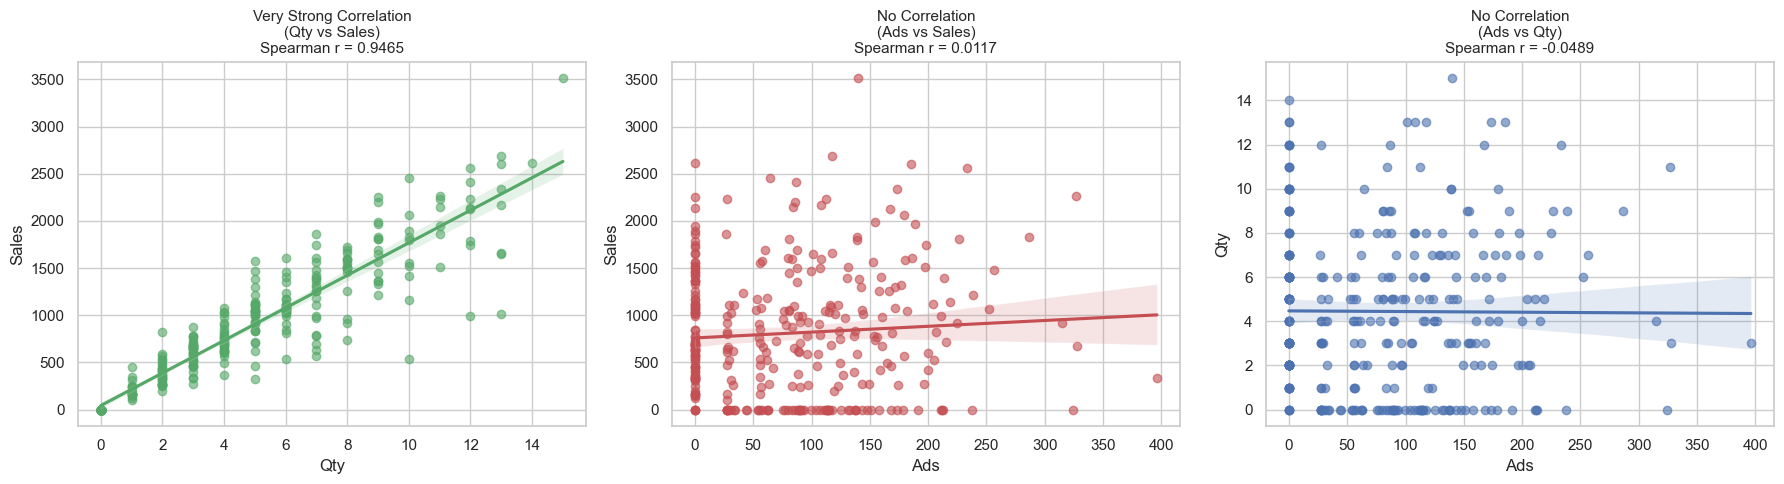

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. ปรับขนาดพื้นที่แบ่งเป็น 1 แถว 3 รูป (1, 3) และขยายความกว้างเฟรมเป็น 18 นิ้ว
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- รูปที่ 1 (ซ้ายสุด): Qty vs Sales ---
sns.regplot(
    x="Qty", y="Sales", data=df, ax=axes[0], color="g", scatter_kws={"alpha": 0.6}
)
axes[0].set_title(
    "Very Strong Correlation\n(Qty vs Sales)\nSpearman r = 0.9465", fontsize=11
)

# --- รูปที่ 2 (ตรงกลาง): Ads vs Sales ---
sns.regplot(
    x="Ads", y="Sales", data=df, ax=axes[1], color="r", scatter_kws={"alpha": 0.6}
)
axes[1].set_title(
    "No Correlation\n(Ads vs Sales)\nSpearman r = 0.0117", fontsize=11
)

# --- รูปที่ 3 (ขวาสุด): Ads vs Qty ---
# เปลี่ยนตำแหน่งชี้ไปที่ axes[2] เพื่อไม่ให้ทับรูปกลาง และแก้ค่าสัมประสิทธิ์ r ให้ตรงกับตาราง (-0.0489)
sns.regplot(
    x="Ads", y="Qty", data=df, ax=axes[2], color="b", scatter_kws={"alpha": 0.6}
)
axes[2].set_title(
    "No Correlation\n(Ads vs Qty)\nSpearman r = -0.0489", fontsize=11
)

plt.tight_layout()
plt.show()